## Imports

In [1]:
# imports
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re
import gseapy as gp
from pybiomart import Dataset
from gseapy import barplot, dotplot
import matplotlib as mpl

## Preparing data for analysis

In [2]:
#loading data

data_sets = {"ZT0Tx vs ZT12Tx" : pd.read_csv('/home/cvillazon/DEseq2_females/ZT0TxvsZT12Tx_females.csv', header=0), 
             "ZT0V vs ZT0Tx" : pd.read_csv('/home/cvillazon/DEseq2_females/ZT0VvsZT0Tx_females.csv', header=0), 
             "ZT0V vs ZT12Tx" : pd.read_csv('/home/cvillazon/DEseq2_females/ZT0VvsZT12Tx_females.csv', header=0), 
             "ZT0V vs ZT12V" : pd.read_csv('/home/cvillazon/DEseq2_females/ZT0VvsZT12V_females.csv', header=0), 
             "ZT12V vs ZT0Tx" : pd.read_csv('/home/cvillazon/DEseq2_females/ZT12VvsZT0Tx_females.csv', header=0), 
             "ZT12V vs ZT12Tx" : pd.read_csv('/home/cvillazon/DEseq2_females/ZT12VvsZT12Tx_females.csv', header=0)
             }


In [3]:
def get_deg(df):
    df['-log10(padj)'] = -np.log10(df['padj'])
    df["regulation"] = np.where((df['padj'] < 0.1) & (df['log2FoldChange'] > 0), 'Up',
                                              np.where((df['padj'] < 0.1) & (df['log2FoldChange'] < 0), 'Down', 
                                                      'Unchange'))

for name, df in data_sets.items():
    get_deg(df)
    data_sets[name] = df

## Volcano plots

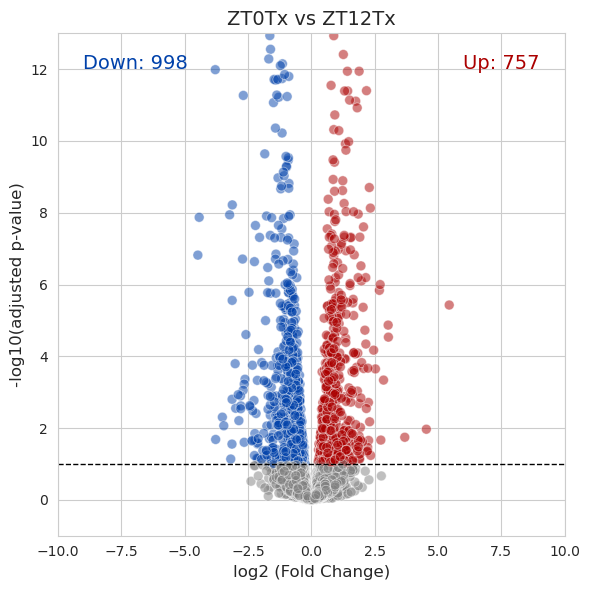

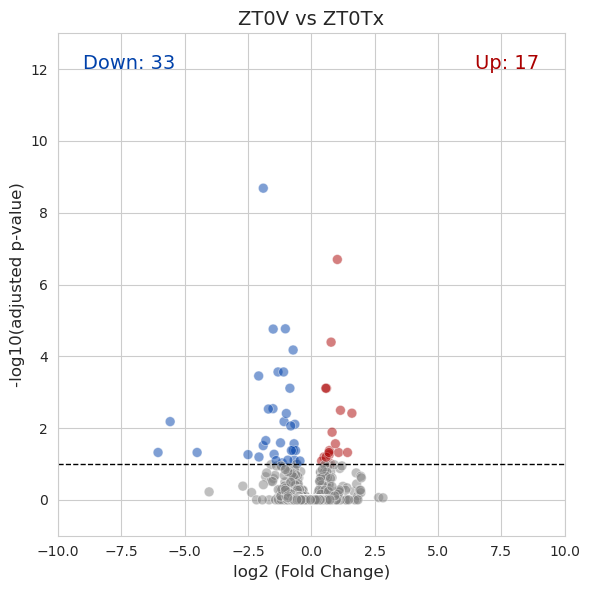

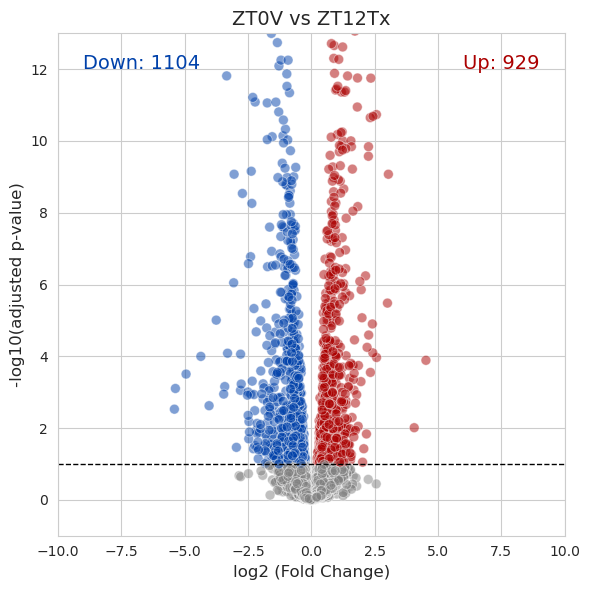

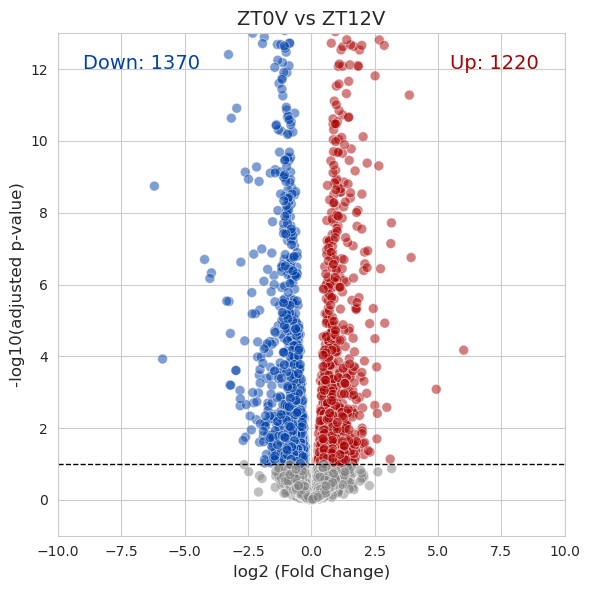

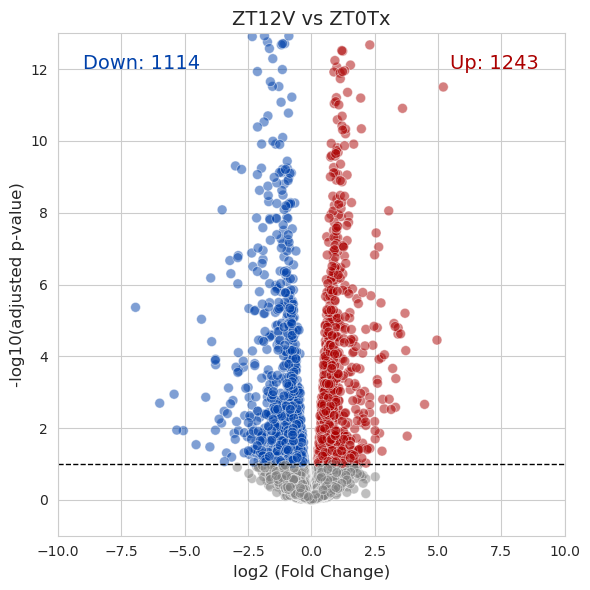

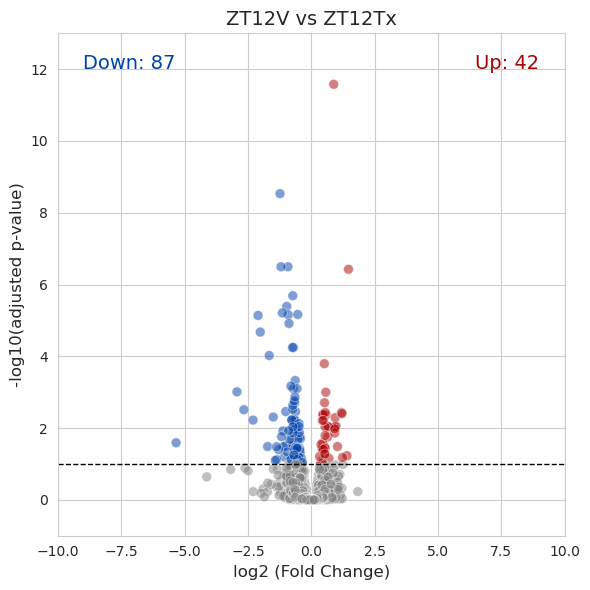

In [5]:
palette = {
    "Up": "#ab0000",      # red
    "Down": "#0041aa",    # blue
    "Unchange": "gray"
}

def volcano_plot(df, title):

    plt.figure(figsize=(6,6))
    with sns.axes_style("whitegrid"):
        sns.scatterplot(
            data=df, 
            x="log2FoldChange", 
            y= "-log10(padj)", 
            hue="regulation",
            palette=palette,
            s=50,
            alpha=0.5,
            legend=None
        )

    # Cutoff lines
    plt.axhline(1, color="black", linestyle="--", linewidth=1)

    # Count categories
    up_count = (df["regulation"] == "Up").sum()
    down_count = (df["regulation"] == "Down").sum()

    plt.text(-9, 12, f"Down: {down_count}", fontsize=14, color='#0041aa', ha='left' )
    plt.text(9, 12, f"Up: {up_count}", fontsize=14, color='#ab0000', ha='right')

    # Labels
    plt.xlabel("log2 (Fold Change)", fontsize=12)
    plt.ylabel("-log10(adjusted p-value)", fontsize=12)
    plt.title(title, fontsize=14)
    plt.xlim(-10,10)
    plt.ylim(-1,13)

    plt.tight_layout()
    plt.show()


for name, df in data_sets.items():
    volcano_plot(df, name)


## Ontologies

In [ ]:
mmus_genes = pd.read_csv("/home/cvillazon/results/mmusculus_genename_go.csv", header=0) 

: 

In [5]:
gene_map = (
    mmus_genes
    .drop_duplicates(subset="Gene stable ID")
    .set_index("Gene stable ID")["Gene name"]
)

for name, df in data_sets.items():
    df["Gene name"] = df.index.map(gene_map)

In [6]:
data_sets['ZT0Tx vs ZT12Tx'].head()


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10(padj),regulation,Gene name
ENSMUSG00000000001,912.960024,0.075510,0.143172,0.527410,0.597909,0.865701,0.062632,Unchange,Gnai3
ENSMUSG00000000028,23.940514,-0.381348,0.486300,-0.784182,0.432933,0.775919,0.110183,Unchange,Cdc45
ENSMUSG00000000031,4.481059,-0.726537,0.949908,-0.764850,0.444361,NaN,NaN,Unchange,H19
ENSMUSG00000000037,0.978215,0.948021,2.187040,0.433472,0.664672,NaN,NaN,Unchange,Scml2
ENSMUSG00000000049,18748.081395,-0.092872,0.113169,-0.820651,0.411845,0.765714,0.115933,Unchange,Apoh


In [ ]:
background = pd.concat([df["Gene name"] for _,df in data_sets.items()])

background = background[~background.duplicated()]
background.to_csv("/home/cvillazon/results/f_background.csv", columns=["Gene name"])
background_lst = [str(gene).upper() for gene in background]

In [9]:
def enrichment_analysis(df, title, gene_set):

    gene_list = list((df[df["regulation"] != "Unchange"]["Gene name"]).dropna())
    gene_list = [str(gene).upper() for gene in gene_list]

    try:
        enr = gp.enrichr(gene_list=gene_list,
                        gene_sets=gene_set, #WikiPathways_2024_Mouse GO_Biological_Process_2025
                        organism='mouse', 
                        background=background_lst,
                        outdir=None, # don't write to disk
                        )
        
        enr.results = enr.results[enr.results["Adjusted P-value"] < 0.05]
        return enr

    except (IndexError, KeyError, AttributeError, TypeError):
        print(f"Skipping {title}")
        return None

enr_res = {name: [] for name in data_sets.keys()}
for name, df in data_sets.items():
    enr_res[name].append(enrichment_analysis(df, name, ['WikiPathways_2024_Mouse']))
    enr_res[name].append(enrichment_analysis(df, name, ['GO_Biological_Process_2025']))

In [10]:
for name in enr_res.keys():
    print(name)
    try:
        print(f'{len(list(enr_res[name][0].results["Term"]))}, {len(list(enr_res[name][1].results["Term"]))}')
    except (IndexError, KeyError, AttributeError, TypeError):
        print(f"Skipping {name}")

ZT0Tx vs ZT12Tx
71, 173
ZT0V vs ZT0Tx
2, 0
ZT0V vs ZT12Tx
50, 196
ZT0V vs ZT12V
41, 234
ZT12V vs ZT0Tx
80, 381
ZT12V vs ZT12Tx
12, 43


In [11]:
gos_sets = []
wiki_sets = []

for name, df in enr_res.items():
    try:
        wiki_sets.append(set(df[0].results['Term']))
        gos_sets.append(set(df[1].results['Term']))
    except (IndexError, KeyError, AttributeError, TypeError):
        print(f"Skipping {name}")

gos = list(set().union(*gos_sets))
wiki = list(set().union(*wiki_sets))


print(f"GO terms: {len(gos)}")
print(f"Wiki terms: {len(wiki)}")

GO terms: 541
Wiki terms: 111


In [ ]:
wiki

['Amino Acid Metabolism WP662',
 'Tryptophan Metabolism WP79',
 'Glucuronidation WP1241',
 'Glycolysis And Gluconeogenesis WP157',
 'ErbB Signaling Pathway WP1261',
 'Integrin Mediated Cell Adhesion WP6',
 'Hedgehog Signaling Pathway WP116',
 'Glutathione And One Carbon Metabolism WP730',
 'Prostaglandin Synthesis And Regulation WP374',
 'Nuclear Receptors WP509',
 'Mechanisms Associated With Pluripotency WP1763',
 'Wnt Signaling WP403',
 'TGF Beta Signaling Pathway WP113',
 'ESC Pluripotency Pathways WP339',
 'Kennedy Pathway WP1771',
 'One Carbon Metabolism WP435',
 'IL 9 Signaling Pathway WP10',
 'Estrogen Metabolism WP1264',
 'Leptin Insulin Signaling Overlap WP578',
 'Nucleotide GPCRs WP207',
 'Oxidative Stress And Redox Pathway WP4466',
 'Focal Adhesion WP85',
 'Triacylglyceride Synthesis WP386',
 'Fatty Acid Biosynthesis WP336',
 'Cholesterol Biosynthesis WP103',
 'MicroRNAs In Cardiomyocyte Hypertrophy WP1560',
 'GPCRs Peptide WP234',
 'Toll Like Receptor Signaling WP88',
 'One

In [ ]:
# Filter for relevant terms with regular expressions

pattern = r'lipid|insulin|glucose|cholesterol|sterol|bile|circadian|nuclear|adipo|estrogen|photoperiod'

relevant_gos = []
for go in gos:
    if re.search(pattern, go, re.IGNORECASE):
        relevant_gos.append(go)

relevant_wiki = []
for wik in wiki:
    if re.search(pattern, wik, re.IGNORECASE):
        relevant_wiki.append(wik)

In [ ]:
print(f"Number of relevant GO terms: {len(relevant_gos)}")
print(f"Number of relevant Wiki terms: {len(relevant_wiki)}")

Number of relevant GO terms: 57
Number of relevant Wiki terms: 14


In [ ]:
relevant_wiki

['Nuclear Receptors WP509',
 'Estrogen Metabolism WP1264',
 'Leptin Insulin Signaling Overlap WP578',
 'Cholesterol Biosynthesis WP103',
 'Dysregulated miRNA Targeting In Insulin PI3K AKT Signaling WP3855',
 'SREBF And miR33 In Cholesterol And Lipid Homeostasis WP2084',
 'Exercise Induced Circadian Regulation WP544',
 'Leptin And Adiponectin WP683',
 'Insulin Signaling WP65',
 'Estrogen Signaling WP1244',
 'Adipogenesis Genes WP447',
 'Cholesterol Metabolism W Bloch And Kandutsch Russell Pathways WP4346',
 'Glycerolipids And Glycerophospholipids WP4345',
 'Nuclear Receptors In Lipid Metabolism And Toxicity WP431']

### Ontology plots

In [ ]:
# Code from Luis Tenorio 

def plot_ontologies(df, title, g_set):
    
    df['-log₁₀ (adjusted p-value)'] = df['Adjusted P-value'].apply(lambda x: -np.log10(x) if pd.notnull(x) and x > 0 else np.nan)
    df['log₂ (Odds Ratio)'] = df['Odds Ratio'].apply(lambda x: np.log2(x) if pd.notnull(x) and x > 0 else np.nan)
    df['Genes count'] = df['Genes'].apply(lambda x: len(x.split(';')) if pd.notnull(x) else 0)
    df = df.sort_values(by='log₂ (Odds Ratio)', ascending=False)
    df = df.head(20)  # Keep only top 20 terms for better visualization
    
    fig, ax = plt.subplots(figsize=(4, 7))

    # --- Scatter ---
    scatter = sns.scatterplot(
        data=df,
        x='log₂ (Odds Ratio)',
        y='Term',
        size='Genes count',
        sizes=(25, 180),
        hue='-log₁₀ (adjusted p-value)',
        palette='magma_r',
        edgecolor='k',
        alpha=0.85,
        legend='brief',
        ax=ax
    )

    # ----------------------------
    # Keep ONLY size legend (upper right)
    # ----------------------------
    handles, labels = ax.get_legend_handles_labels()
    size_start = labels.index('Genes count')

    size_legend = ax.legend(
        handles[size_start:],
        labels[size_start:],
        bbox_to_anchor=(1, 1),
        loc='upper left',
        frameon=False
    )

    # ----------------------------
    # Create smaller colorbar axis
    # ----------------------------
    norm = mpl.colors.Normalize(
        vmin=df['-log₁₀ (adjusted p-value)'].min(),
        vmax=df['-log₁₀ (adjusted p-value)'].max()
    )

    sm = mpl.cm.ScalarMappable(
        cmap='magma_r',
        norm=norm
    )
    sm.set_array([])

    # Manually position colorbar (right lower corner)
    cax = fig.add_axes([0.88, 0.15, 0.03, 0.3])
    # [left, bottom, width, height]  → tweak if needed

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label('-log₁₀ (adjusted p-value)')

    # ----------------------------
    # Layout tweaks
    # ----------------------------
    ax.set_ylabel(None)
    ax.set_title("{} - {}".format(title, g_set), fontsize=12)

    plt.subplots_adjust(right=0.8)  # Make space for legends

/tmp/ipykernel_22518/2130901833.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(


Skipping ZT0V vs ZT0Tx


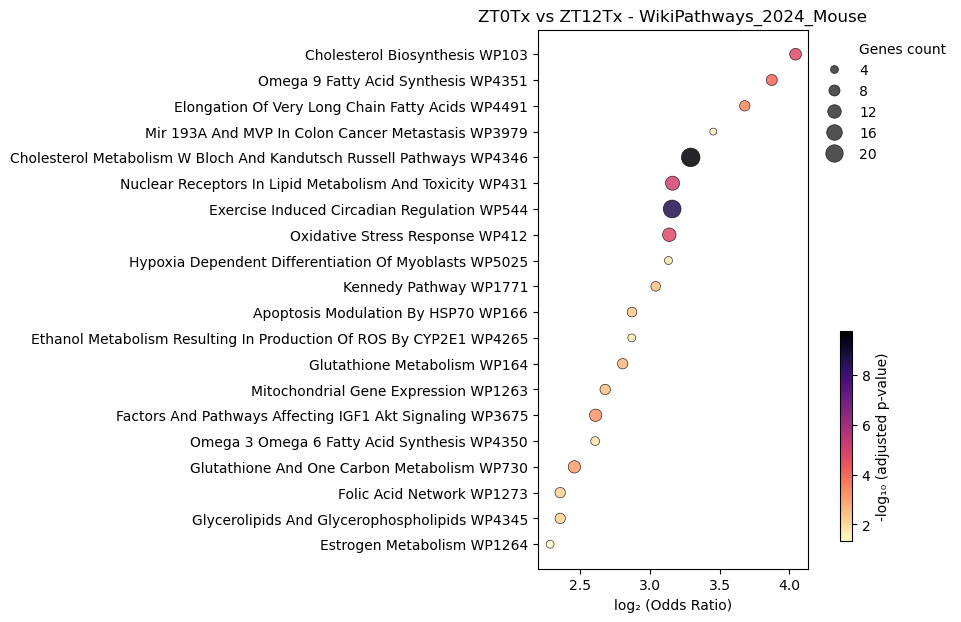

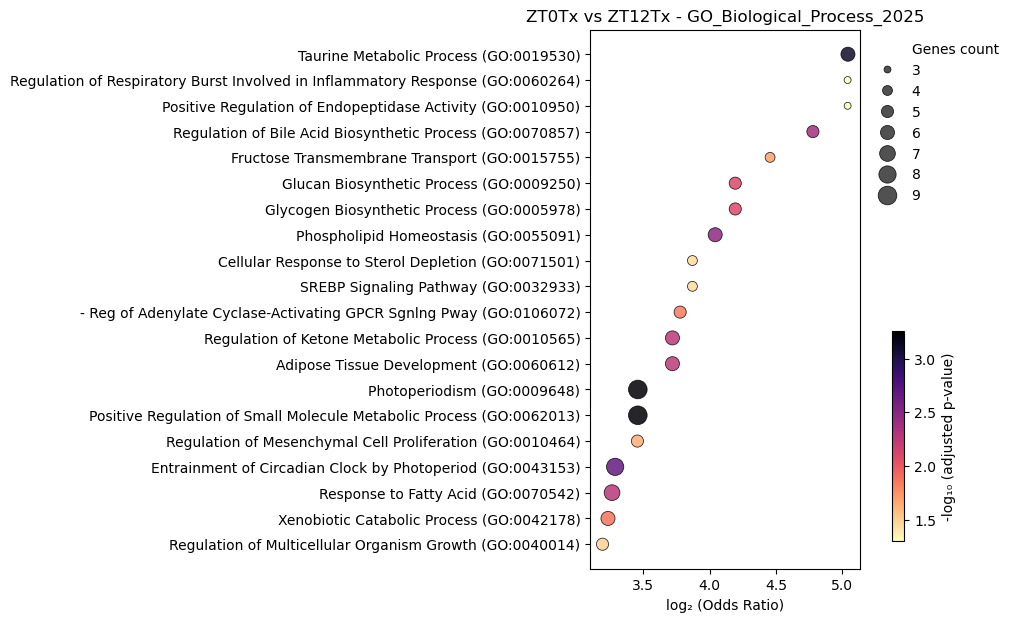

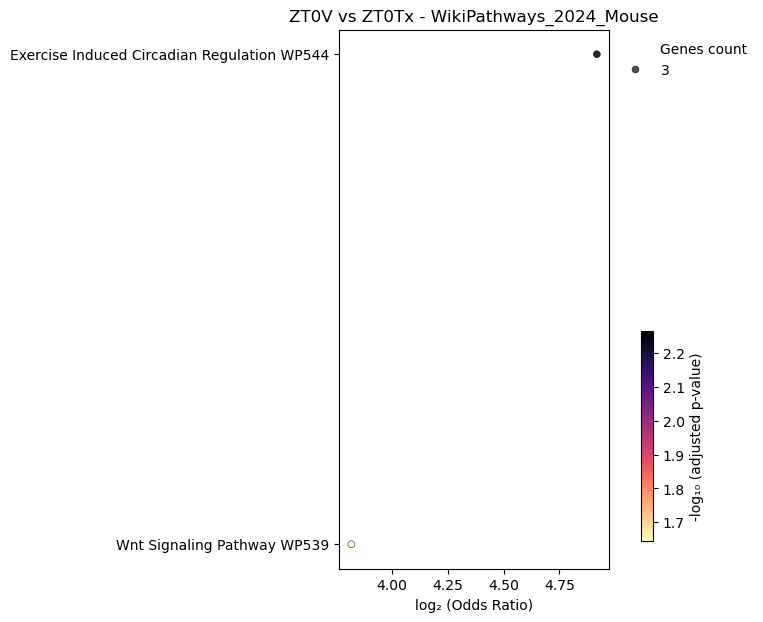

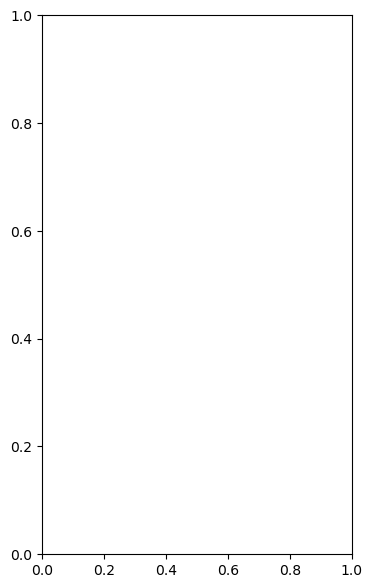

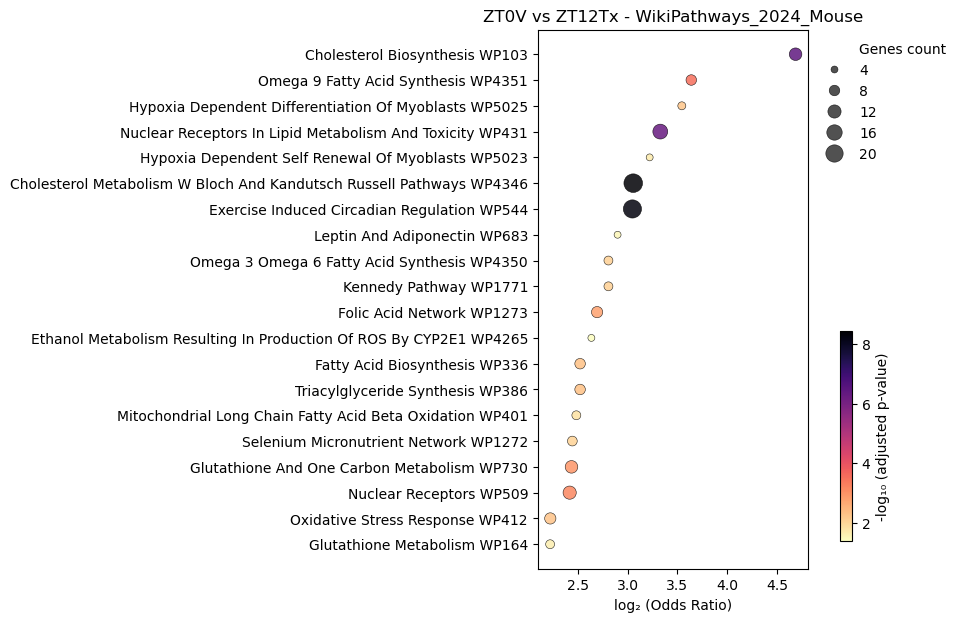

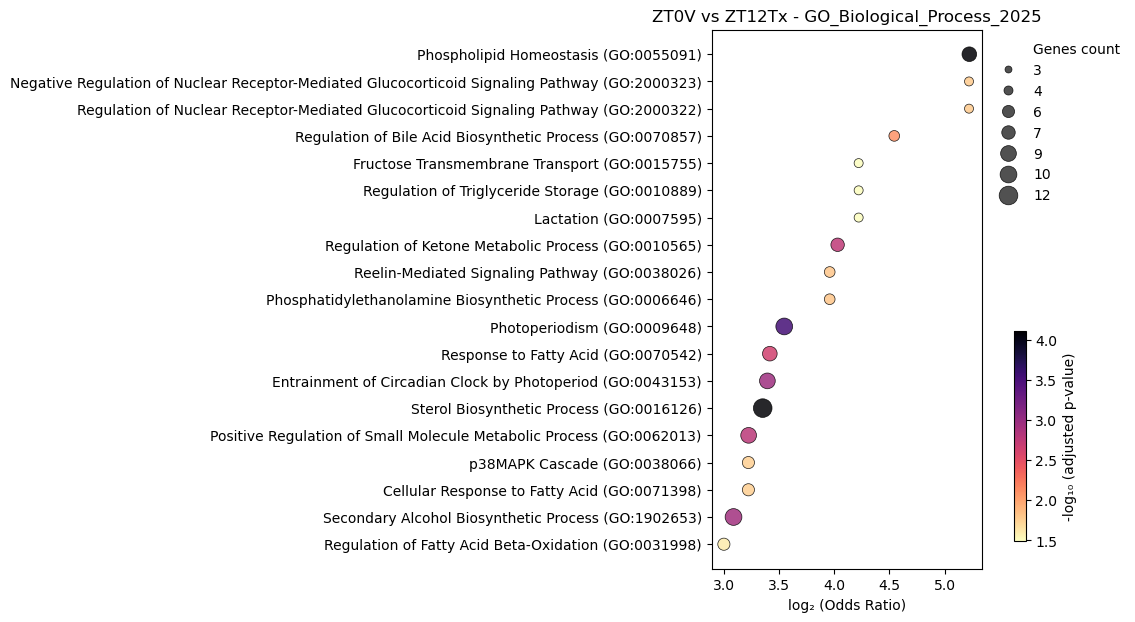

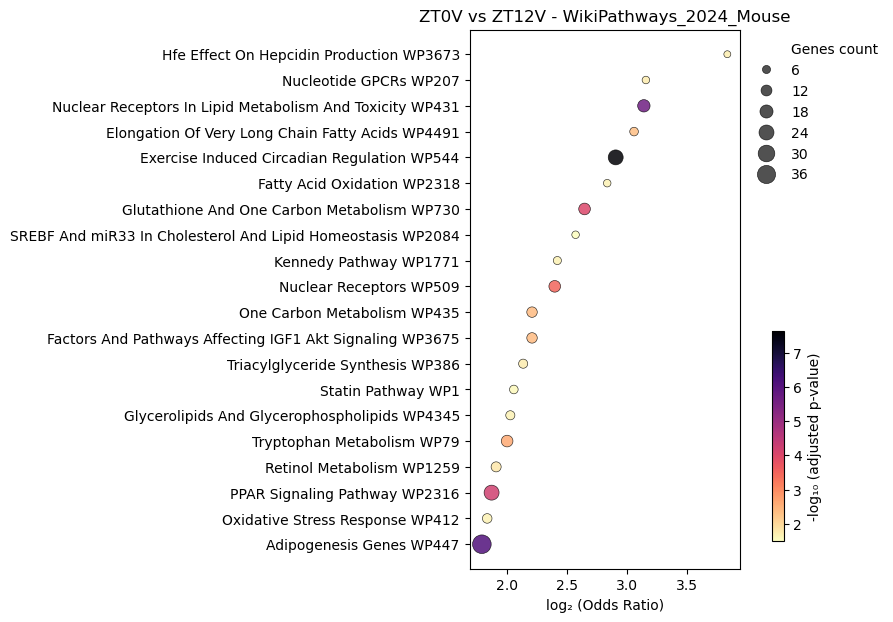

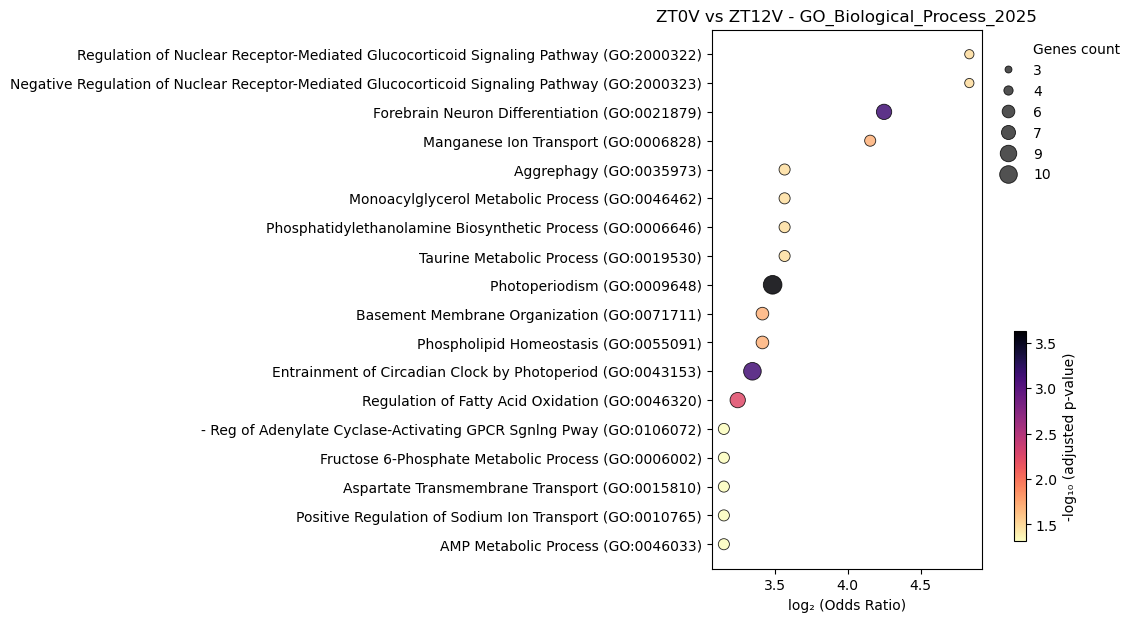

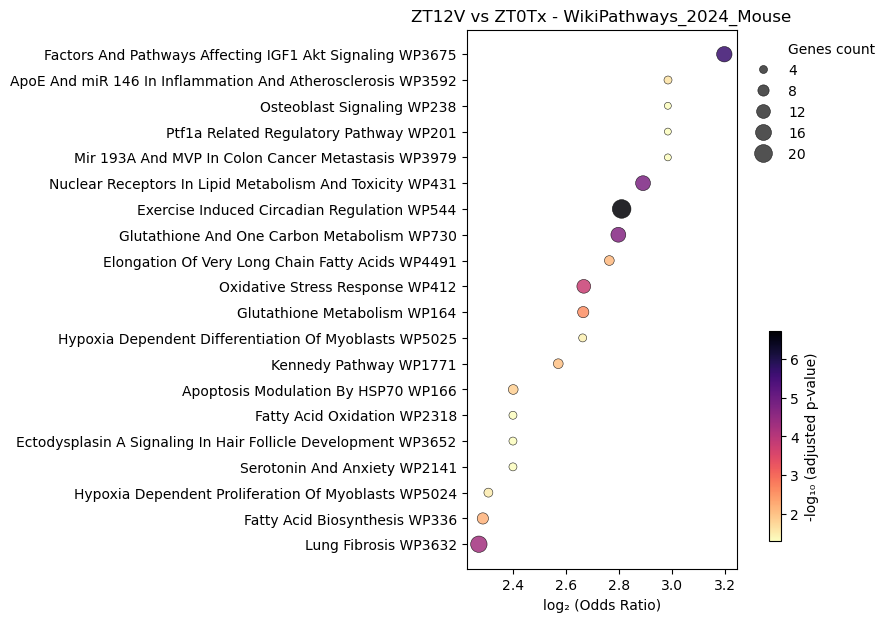

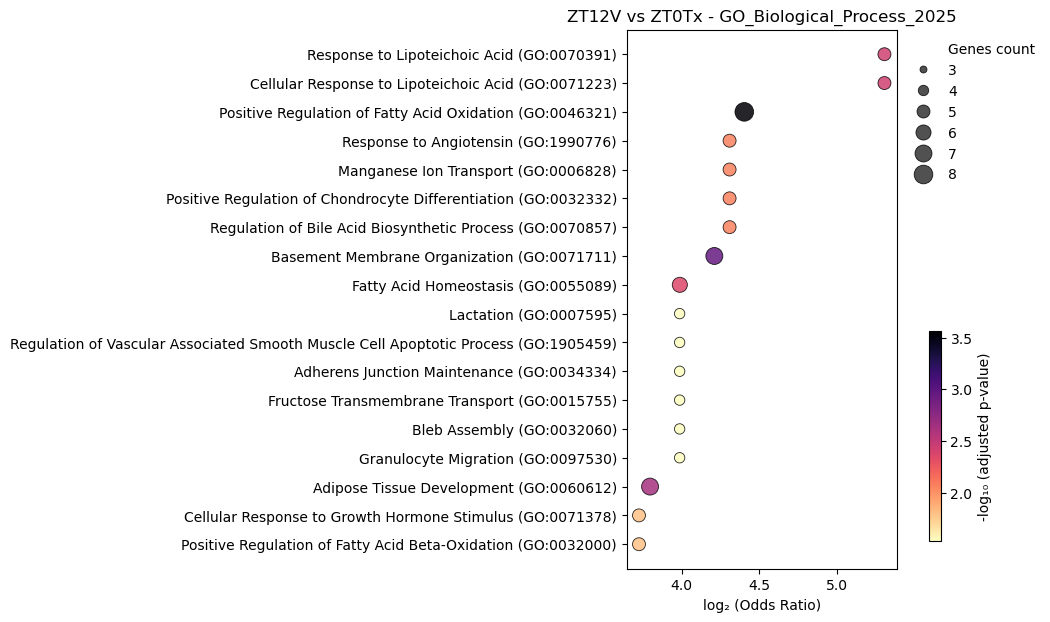

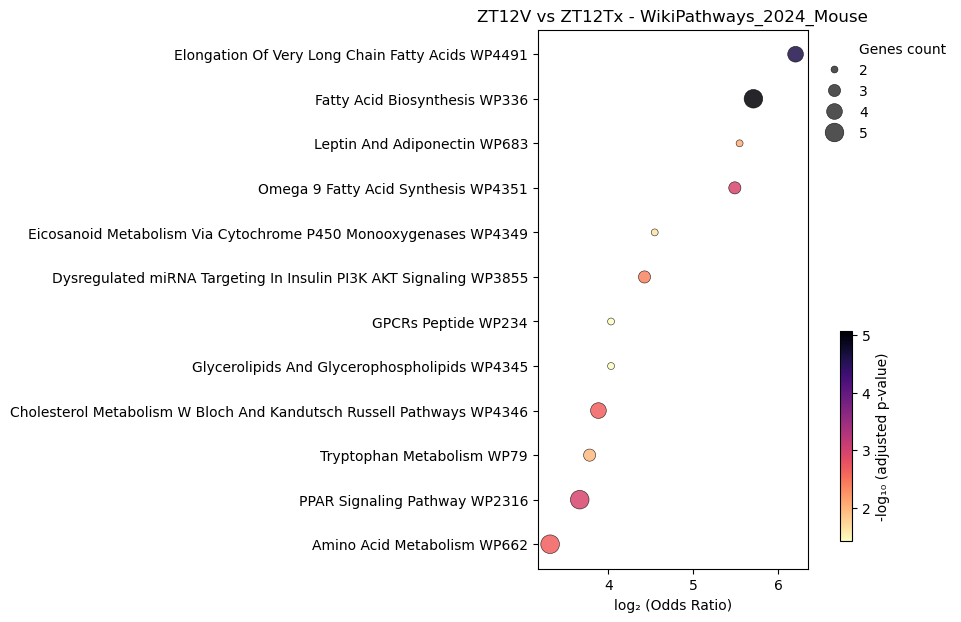

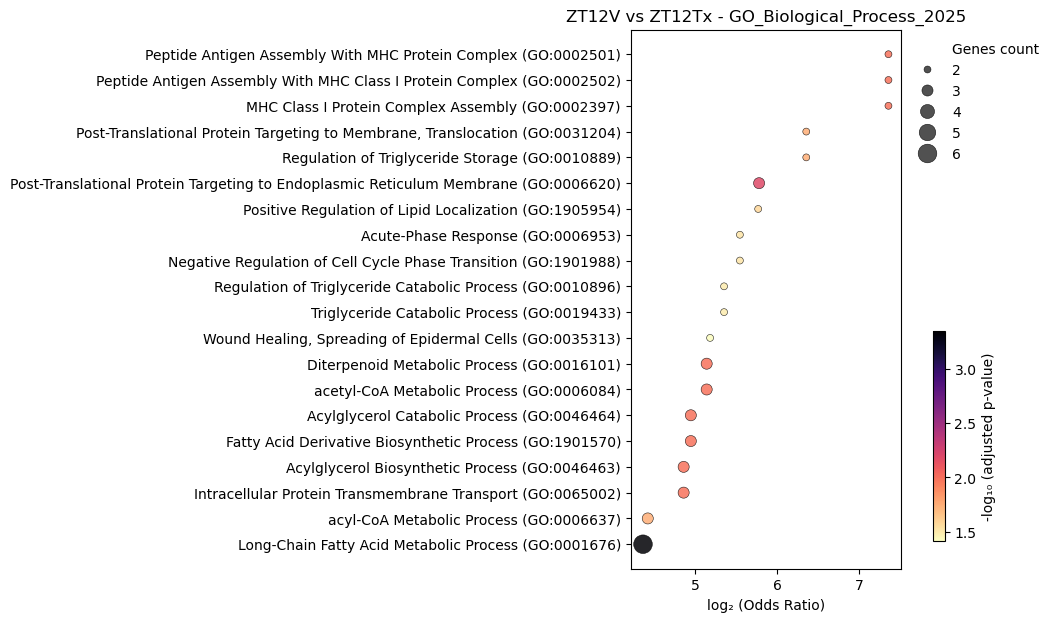

In [ ]:
for name, df in enr_res.items():
    try:
        plot_ontologies(df[0].results, name, 'WikiPathways_2024_Mouse')
        plot_ontologies(df[1].results, name, 'GO_Biological_Process_2025')
    except (IndexError, KeyError, AttributeError, TypeError, ValueError):
        print(f"Skipping {name}")

## GSVA

In [ ]:
pw_genes = pd.DataFrame(columns=['ensembl_gene_id', 'external_gene_name'])

for _, df in data_sets.items():
    pw_genes = pd.concat([pw_genes, df[df["regulation"] != "Unchange"][['ensembl_gene_id', 'external_gene_name']].drop_duplicates()])

pw_genes.head()

,ensembl_gene_id,external_gene_name
26401.0,ENSMUSG00000000056,Narf
28856.0,ENSMUSG00000000120,Ngfr
15037.0,ENSMUSG00000000134,Tfe3
20642.0,ENSMUSG00000000142,Axin2
23037.0,ENSMUSG00000000149,Gna12


In [ ]:
# Prepare data for GSVA

# Load counts for later use in enrichment analysis with GSEApy

counts = pd.read_csv('/home/cvillazon/results/mRNA_SNAKEPipes_out/featureCounts/counts_female.tsv', sep='\t', header=0)

counts = counts[['gene', 'ZT0_Tx_rep2_hem','ZT0_Tx_rep4_hem','ZT0_V_rep2_hem',
                 'ZT0_V_rep3_hem','ZT0_V_rep4_hem','ZT12_Tx_rep2_hem',
                 'ZT12_Tx_rep3_hem','ZT12_Tx_rep4_hem','ZT12_V_rep2_hem',
                 'ZT12_V_rep3_hem','ZT12_V_rep4_hem'
                    ]].set_index('gene')

ZTs_counts = counts.loc[counts.index.isin(list(pw_genes['ensembl_gene_id']))]

ZTs_counts = pd.merge(left=ZTs_counts, right=pw_genes, left_index=True, right_on='ensembl_gene_id', how='left')

ZTs_counts = ZTs_counts.drop(columns=["ensembl_gene_id"])

ZTs_counts = ZTs_counts.rename(columns={"external_gene_name": "gene", 'ZT0_Tx_rep2_hem':'ZT0_Tx_rep2','ZT0_Tx_rep4_hem':'ZT0_Tx_rep4','ZT0_V_rep2_hem':'ZT0_V_rep2',
                 'ZT0_V_rep3_hem':'ZT0_V_rep3','ZT0_V_rep4_hem':'ZT0_V_rep4','ZT12_Tx_rep2_hem':'ZT12_Tx_rep2',
                 'ZT12_Tx_rep3_hem':'ZT12_Tx_rep3','ZT12_Tx_rep4_hem':'ZT12_Tx_rep4','ZT12_V_rep2_hem':'ZT12_V_rep2',
                 'ZT12_V_rep3_hem':'ZT12_V_rep3','ZT12_V_rep4_hem':'ZT12_V_rep4'})

ZTs_counts["gene"] = ZTs_counts["gene"].str.upper()

ZTs_counts = ZTs_counts.set_index('gene')

##Filter expressed genes 
### Keep only genes with counts > 10 in at least 50% of samples
threshold = 10
fraction = 0.5

ZTs_exp_counts  = ZTs_counts[
        (ZTs_counts.iloc[:, 1:] > threshold).sum(axis=1) >= fraction * (ZTs_counts.shape[1] - 1)
    ]

# Step 1: Calculate geometric mean per gene
geom_means = ZTs_exp_counts.apply(lambda x: np.exp(np.log(x.replace(0, np.nan)).mean()), axis=1)
    
# Step 2: Compute size factors (median ratio per sample)
size_factors = ZTs_exp_counts.div(geom_means, axis=0).median(axis=0)
    
# Step 3: Normalize counts
norm_exp_df = ZTs_exp_counts.div(size_factors, axis=1)

normalized_counts = norm_exp_df.reset_index()


def reshape_gene_counts(df):
    # Melt the dataframe to long format
    tidy_df = df.melt(id_vars='gene', var_name='Experiment', value_name='Normalized Counts')

    # Extract Diet, Circadian time and rep
    tidy_df[['Circadian Time', 'Treatment','rep']] = tidy_df['Experiment'].str.split('_', expand=True)

    # Combine both treatment and Circadian Time for a condition
    tidy_df['Condition'] = tidy_df['Treatment'] + ' ' + tidy_df['Circadian Time']

    # Replace Experiment to be space sepatared for visualizing purposes
    tidy_df['Experiment'] = tidy_df['Condition'] + " " + tidy_df['rep']
    

    return tidy_df

tidy_counts = reshape_gene_counts(normalized_counts)

genes_cond_pivot = pd.pivot_table(tidy_counts, index='gene', columns='Condition', 
                              values='Normalized Counts')
genes_cond_pivot = genes_cond_pivot.dropna()

genes_cond_upper_pivot = genes_cond_pivot.copy()

genes_cond_upper_pivot.index = genes_cond_pivot.index.str.upper()




In [ ]:
genes_cond_upper_pivot.head()

Condition,Tx ZT0,Tx ZT12,V ZT0,V ZT12
gene,,,,
0610005C13RIK,1529.290298,1917.645214,1633.960693,1900.294421
0610030E20RIK,552.949970,300.830634,551.043917,300.654482
0610031O16RIK,178.353437,250.161171,259.985033,315.005997
0610043K17RIK,35.554860,26.270837,20.994741,53.994433
1110059E24RIK,65.836482,96.706526,65.083421,97.422721


In [ ]:
# extracting genes and pathways
pathway_gene_sets_GO = {}

for name, df in enr_res.items():
    for _, row in df[1].results.iterrows():
        pathway = row["Term"]
        genes = [
            g.strip().upper()
            for g in str(row["Genes"]).split(";")
            if g.strip()
        ]
        pathway_gene_sets_GO[pathway] = genes

pathway_gene_sets_Wiki = {}
for name, df in enr_res.items():
    for _, row in df[0].results.iterrows():
        pathway = row["Term"]
        genes = [
            g.strip().upper()
            for g in str(row["Genes"]).split(";")
            if g.strip()
        ]
        pathway_gene_sets_Wiki[pathway] = genes

In [ ]:
expr_genes = set(str(gene).upper() for gene in pw_genes["external_gene_name"])

pathway_gene_sets_GO = {
    pw: list(set(genes) & expr_genes)
    for pw, genes in pathway_gene_sets_GO.items()
    if len(set(genes) & expr_genes) >= 5  # minimum size
}

pathway_gene_sets_Wiki = {
    pw: list(set(genes) & expr_genes)
    for pw, genes in pathway_gene_sets_Wiki.items()
    if len(set(genes) & expr_genes) >= 5  # minimum size
}

In [ ]:
pathway_gene_sets_GO = {key: value for key, value in pathway_gene_sets_GO.items() if key in relevant_gos}

pathway_gene_sets_Wiki = {key: value for key, value in pathway_gene_sets_Wiki.items() if key in relevant_wiki}

print(f"GO pathways: {len(pathway_gene_sets_GO)}")
print(f"Wiki pathways: {len(pathway_gene_sets_Wiki)}")

GO pathways: 49
Wiki pathways: 9


In [ ]:
import json
with open('pathway_gene_sets_GO.json', 'w') as fout:
    json.dump(pathway_gene_sets_GO, fout)

with open('pathway_gene_sets_Wiki.json', 'w') as fout:
    json.dump(pathway_gene_sets_Wiki, fout)

In [ ]:
expr_gsva = genes_cond_pivot.copy()
expr_gsva = expr_gsva[~expr_gsva.index.duplicated()] # ~ boolean negation
expr_gsva = expr_gsva.dropna()
expr_gsva.index = expr_gsva.index.astype(str)
expr_gsva.index.name = None
expr_gsva.columns.name = None

expr_for_gsva = expr_gsva.copy()

# force gene names (now columns) to string
expr_for_gsva.columns = expr_for_gsva.columns.astype(str)

expr_for_gsva.columns = (
    expr_for_gsva.columns
    .map(str)
    .str.replace(r"\.0$", "", regex=True)
)

expr_for_gsva = pd.DataFrame(
    expr_for_gsva.values,
    index=expr_for_gsva.index.astype(str),
    columns=expr_for_gsva.columns.astype(str),
)

#gsva_res_GO = gp.gsva(
#    data=expr_gsva,
#    gene_sets=pathway_gene_sets_GO,
#    method='gsva',#"gsva",
#    min_size=5,
#    max_size=500,
#    verbose=True
#)

#gsva_res_Wiki = gp.gsva(
#    data=expr_for_gsva,
#    gene_sets=pathway_gene_sets_Wiki,
#    method="gsva",
#    min_size=5,
#    max_size=500,
#    verbose=True
#)

#gsva_scores_GO = gsva_res_GO.res2d

#gsva_scores_Wiki = gsva_res_Wiki.res2d

In [ ]:
expr_for_gsva.to_csv('expr_for_gsva.csv')

In [ ]:
gsva_scores_Wiki = pd.read_csv("/home/cvillazon/DEseq2_females/gsva_es_wiki.csv", header=0, index_col=0)

gsva_scores_GO = pd.read_csv("/home/cvillazon/DEseq2_females/gsva_es_go.csv", header=0, index_col=0)

In [ ]:
gsva_scores_Wiki

,Tx.ZT0,Tx.ZT12,V.ZT0,V.ZT12
Exercise Induced Circadian Regulation WP544,-0.140057,-0.103728,0.012620,0.247768
Nuclear Receptors In Lipid Metabolism And Toxicity WP431,-0.406451,-0.106981,-0.071157,0.551888
Cholesterol Biosynthesis WP103,-0.521364,0.836223,-0.519872,-0.113897
Adipogenesis Genes WP447,0.084203,-0.075648,-0.013414,0.053769
Nuclear Receptors WP509,-0.429380,0.221075,-0.074259,0.353003
Estrogen Signaling WP1244,0.046168,-0.263531,0.118878,0.056845
Insulin Signaling WP65,-0.104897,0.107308,-0.252677,0.294296
SREBF And miR33 In Cholesterol And Lipid Homeostasis WP2084,-0.682065,0.466859,-0.516112,0.578429
Leptin Insulin Signaling Overlap WP578,0.353287,-0.392810,0.320373,-0.433198


In [ ]:
#heatmap_df_GO = (
#    gsva_scores_GO
#    .pivot(index="Unnamed: 0", columns= ("Tx.ZT0", "Tx.ZT12", "V.ZT0", "V.ZT12"))#, columns="Name", values="ES")
#)
heatmap_df_GO = gsva_scores_GO

condition_order = ["Tx.ZT0", "Tx.ZT12", "V.ZT0", "V.ZT12"]

heatmap_df_GO = heatmap_df_GO[condition_order]

heatmap_df_GO = heatmap_df_GO.fillna(0)

In [ ]:
# Define the colors
colors = ['#0041aa','#fefefe','#ab0000']

# Create the colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', colors)

/home/seisbio/miniforge/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


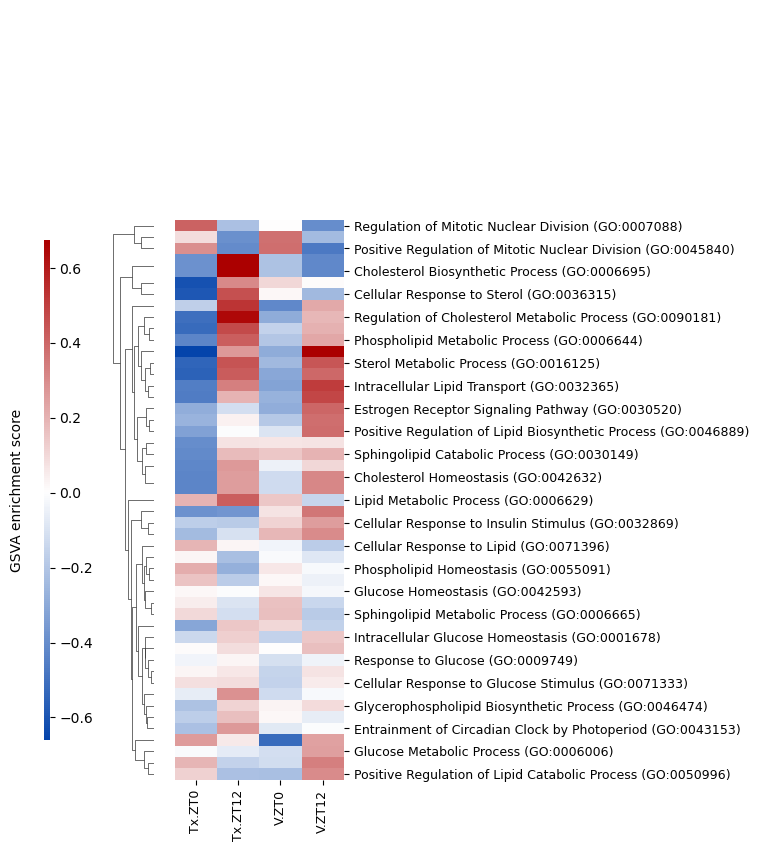

In [ ]:
g = sns.clustermap(
    heatmap_df_GO,
    cmap=custom_cmap,
    center=0,
    #linewidths=0.5,
    figsize=(3, 10),
    cbar_pos=(-0.1, 0.15, 0.02, 0.5),  # right-center
    col_cluster=False
)

# Rotate & resize x tick labels
plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=0,
    ha="center",
    fontsize=8
)

# Optional: resize y labels
plt.setp(
    g.ax_heatmap.get_yticklabels(),
    fontsize=9
)

# Optional: colorbar label
g.cax.set_ylabel(
    "GSVA enrichment score",
    rotation=90,
    labelpad=-60
)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_xticklabels(
    heatmap_df_GO.columns,
    rotation=90,
    #ha="center",
    fontsize=9
)
g.ax_heatmap.set_ylabel("")
plt.savefig('GSVA_cluster_go.pdf', bbox_inches='tight')
plt.show()

In [ ]:
heatmap_df_Wiki = gsva_scores_Wiki

condition_order = ["Tx.ZT0", "Tx.ZT12", "V.ZT0", "V.ZT12"]

heatmap_df_Wiki = heatmap_df_Wiki[condition_order]

heatmap_df_Wiki = heatmap_df_Wiki.fillna(0)

/home/seisbio/miniforge/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


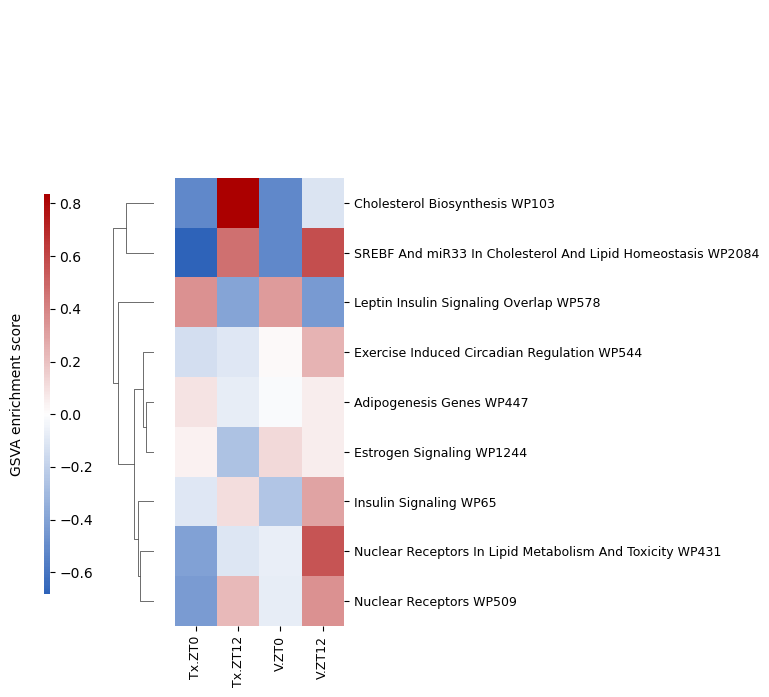

In [ ]:
g = sns.clustermap(
    heatmap_df_Wiki,
    cmap=custom_cmap,
    center=0,
    #linewidths=0.5,
    figsize=(3, 8),
    cbar_pos=(-0.1, 0.15, 0.02, 0.5),  # right-center
    col_cluster=False
)

# Rotate & resize x tick labels
plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=0,
    ha="center",
    fontsize=8
)

# Optional: resize y labels
plt.setp(
    g.ax_heatmap.get_yticklabels(),
    fontsize=9
)

# Optional: colorbar label
g.cax.set_ylabel(
    "GSVA enrichment score",
    rotation=90,
    labelpad=-60
)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_xticklabels(
    heatmap_df_Wiki.columns,
    rotation=90,
    #ha="center",
    fontsize=9
)
g.ax_heatmap.set_ylabel("")
plt.savefig('GSVA_cluster_wiki.pdf', bbox_inches='tight')
plt.show()